# Tree boosting main idea
## Data
- Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]
- Individual medical costs billed by health insurance
- EDA: e.g [https://datauab.github.io/medical_insurance/]
- Preprocessed, split into training and test set and saved in pickle file

## Task
- Develop a toy bossting machine to model
- One dimensional relation
- Target: charges
- Feature: bmi 

In [9]:
### Dependencies
import numpy as np
import matplotlib.pyplot as plt #basic graphs
import pandas as pd
import pickle

# Used models
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error # MSE
from sklearn.tree import plot_tree #tree to plot tree

SEED = 500

In [10]:
# import gdown
#In colab, you need to download the file first and save it locally 
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
# file_path = 'insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

In [11]:
# Load the file
file_path = '../data/insurance_train_test.pkl'
with open(file_path, "rb") as input_file:
    X_train, X_test, y_train, y_test = pickle.load(input_file)

# Alias for columns
y = 'charges' # response
x = 'bmi'     # single feature

In [12]:
display(X_train)

,age,bmi,children,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
381,55,30.7,0,True,True,True,False,False,False
959,48,36.7,1,True,False,False,True,False,False
526,19,30.6,2,False,False,False,True,False,False
1016,19,24.6,1,False,False,False,True,False,False
1032,30,27.9,0,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
287,63,26.2,0,False,False,False,True,False,False
957,24,26.8,1,True,False,False,True,False,False
273,50,27.5,1,True,False,True,False,False,False
951,51,42.9,2,True,True,False,False,True,False


Mean charges for smokers:  32190.901538461538


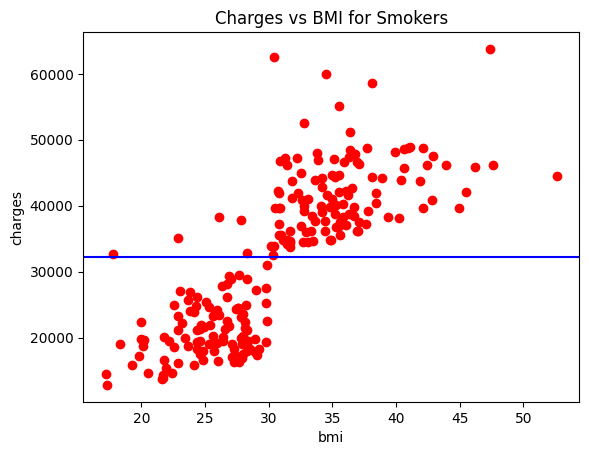

In [13]:
# Select only smokers for training
dat = pd.concat([X_train[x], y_train], axis=1)
dat = dat.loc[X_train['smoker_yes'] == 1, :]  # keep only smokers
dat = dat.sort_values(x)                      # sort by bmi
dat.head()

# Mean of charges among smokers in training set
mean_y = dat[y].mean()  # fill in the blank here
print('Mean charges for smokers: ', mean_y)

# Scatter plot
plt.scatter(dat[x], dat[y], color='red')
plt.xlabel(x)
plt.ylabel(y)
plt.title('Charges vs BMI for Smokers')
# add horizontal line for mean
plt.axhline(y=mean_y, color='b', linestyle='-')
plt.show()




In [14]:
# Do the same for test data that we will use for validation
dat_valid = pd.concat([X_test[x], y_test], axis=1)
dat_valid = dat_valid.loc[X_test['smoker_yes'] == 1, :]
dat_valid = dat_valid.sort_values(x)
dat_valid.head()


,bmi,charges
380,18.0,15006.58
1100,19.1,16776.30
994,20.0,16420.49
793,20.9,21195.82
1306,21.9,16115.30


In [15]:
# Initial model: constant prediction (mean_y)
i_run = 0  # initial model index
dat["pred"+str(i_run)] = mean_y          # fill in the blank here
dat_valid["pred"+str(i_run)] = mean_y    # same for validation

# Calculate MSE of the initial model (training)
mse_boosters = [mean_squared_error(dat[y], dat['pred'+str(i_run)])]
print('MSE for initial model (train):', mse_boosters[-1])

# Calculate MSE of the initial model (validation)
mse_boosters_valid = [mean_squared_error(dat_valid[y], dat_valid['pred'+str(i_run)])]
print('MSE for initial model (valid):', mse_boosters_valid[-1])


MSE for initial model (train): 135195077.8502827
MSE for initial model (valid): 122507673.0407536


<font color='DodgerBlue'>
Perform 10 iterations of boosting and collect MSE for training and validation set for each iteration: <br>
<ol>
<li> Calculate <b>residuals</b> (The difference between the response variable and the current predictions) for the training data.
<li> <b>Fit a decision tree to the residuals.</b> Use only a stump (max_depth=1). Other HP remain default.
<li> Calculate the <b>predictions</b> of the <b>residulas</b> using the new model, for boths training and validation data.
<li> <b>Update current predictions</b> of the model by adding the predictions of the new residual model (=add new basis) for both training and validation data. 
<li> <b>Update MSE</b> for training and validation data. 
<li> Draw some plots to see what is going on during first 5 iterations. 
</ol>
</font>

Iteration 1 | Train MSE: 31303825.08, Valid MSE: 24662313.98


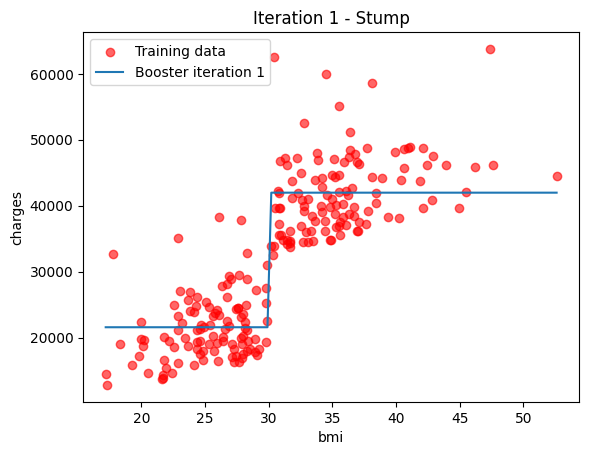

Iteration 2 | Train MSE: 29543218.93, Valid MSE: 25001635.38


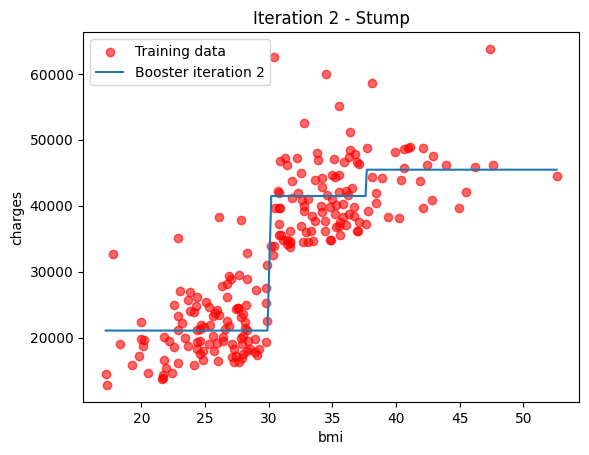

Iteration 3 | Train MSE: 28445591.12, Valid MSE: 23984570.45


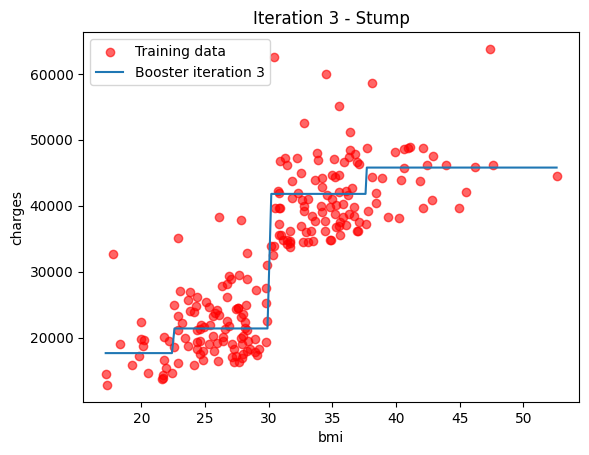

Iteration 4 | Train MSE: 27773367.45, Valid MSE: 22753587.56


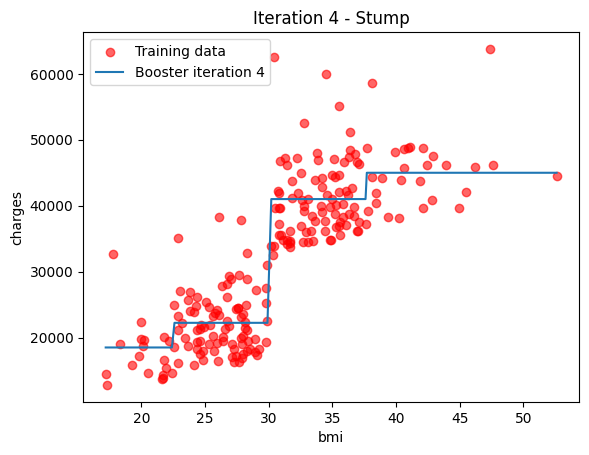

Iteration 5 | Train MSE: 27197769.08, Valid MSE: 22607291.76


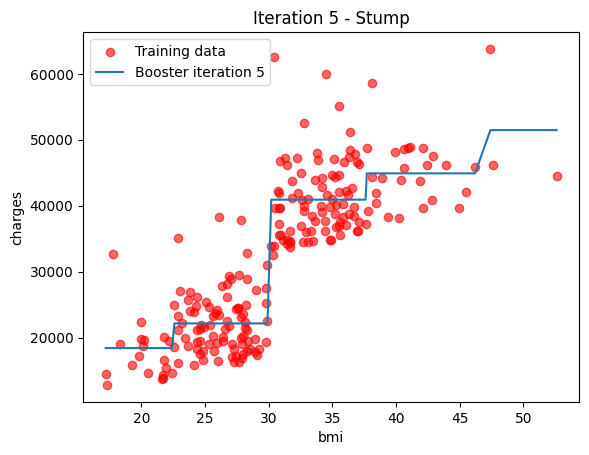

Iteration 6 | Train MSE: 26851872.12, Valid MSE: 22697834.43
Iteration 7 | Train MSE: 26588467.09, Valid MSE: 22551891.15
Iteration 8 | Train MSE: 26406210.16, Valid MSE: 22618648.04
Iteration 9 | Train MSE: 26081013.65, Valid MSE: 23541406.82
Iteration 10 | Train MSE: 25865205.92, Valid MSE: 23620146.89


In [17]:
from sklearn.tree import DecisionTreeRegressor

# Number of boosting iterations
nBoost = 10
# We'll do some quick plots in the first few iterations just to visualize
nPlotBoost = 5  

for i_run in range(nBoost):
    # 1) Calculate residuals for the training data
    #    Residual = actual y - current prediction
    res_train = dat[y] - dat["pred" + str(i_run)]
    
    # 2) Fit a decision tree (stump) to the residuals
    #    max_depth=1 => stump
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED)
    stump.fit(dat[[x]], res_train)
    
    # 3) Predict the residuals for both training and validation
    rhat_train = stump.predict(dat[[x]])           # predicted residuals (train)
    rhat_valid = stump.predict(dat_valid[[x]])     # predicted residuals (valid)
    
    # 4) Update current predictions by adding the new tree’s output
    dat["pred" + str(i_run + 1)] = dat["pred" + str(i_run)] + rhat_train
    dat_valid["pred" + str(i_run + 1)] = dat_valid["pred" + str(i_run)] + rhat_valid
    
    # 5) Update MSE for training and validation
    mse_boosters.append(
        mean_squared_error(dat[y], dat["pred" + str(i_run + 1)])
    )
    mse_boosters_valid.append(
        mean_squared_error(dat_valid[y], dat_valid["pred" + str(i_run + 1)])
    )
    
    print(f"Iteration {i_run+1} | "
          f"Train MSE: {mse_boosters[-1]:.2f}, "
          f"Valid MSE: {mse_boosters_valid[-1]:.2f}")
    
    # 6) (Optional) Draw some plots for the first few iterations
    #    so we can see how the model is fitting
    if i_run < nPlotBoost:
        plt.scatter(dat[x], dat[y], color='red', alpha=0.6, label='Training data')
        plt.plot(dat[x], dat["pred" + str(i_run + 1)], label=f'Booster iteration {i_run+1}')
        plt.title(f'Iteration {i_run+1} - Stump')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.show()




<font color='DodgerBlue'>
<b>Plot MSE</b> for training and validation data for each iteration. <br>
Find the <b>optimal number of iterations</b>. <br>
<b> Create boxplots for residuals</b> for first 5 iterations. What is going on with its variance? <br>
</font>

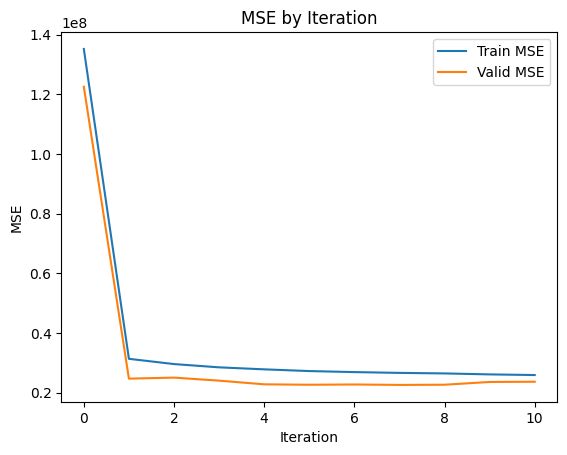

Optimal iteration index: 7
Minimum validation MSE: 22551891.15259255


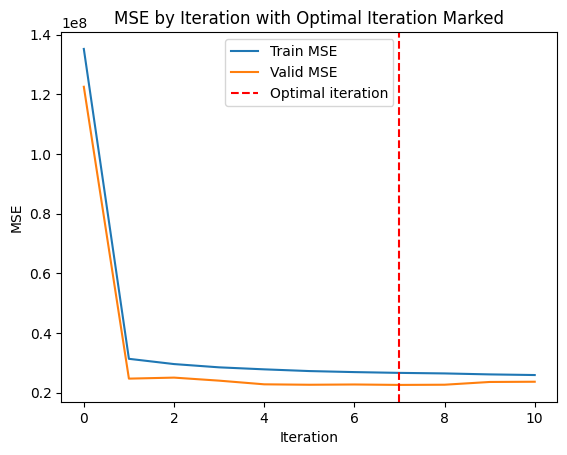

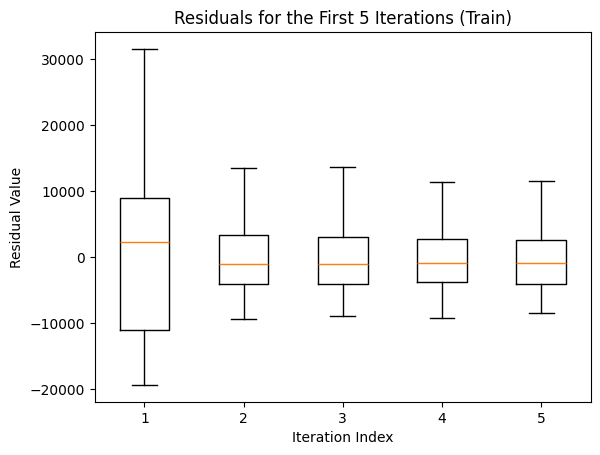

In [18]:
import numpy as np

# 1) Plot MSE for training and validation
plt.plot(range(len(mse_boosters)), mse_boosters, label='Train MSE')
plt.plot(range(len(mse_boosters_valid)), mse_boosters_valid, label='Valid MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE by Iteration')
plt.legend()
plt.show()

# 2) Find the optimal number of iterations (minimum validation MSE)
best_iter = np.argmin(mse_boosters_valid)  # returns the index of min value
print(f"Optimal iteration index: {best_iter}")
print(f"Minimum validation MSE: {mse_boosters_valid[best_iter]}")

# Optional: Re-plot the MSE curves and add a vertical line at best_iter
plt.plot(range(len(mse_boosters)), mse_boosters, label='Train MSE')
plt.plot(range(len(mse_boosters_valid)), mse_boosters_valid, label='Valid MSE')
plt.axvline(x=best_iter, color='r', linestyle='--', label='Optimal iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE by Iteration with Optimal Iteration Marked')
plt.legend()
plt.show()

# 3) Create boxplots for residuals over the first 5 iterations
#    First, calculate & store the residual columns if not already done.
#    We have predictions pred0, pred1, ..., so let's create res0, res1, ...
for i in range(6):  # i.e. up to iteration 5
    col_pred = f"pred{i}"
    col_res = f"res{i}"
    dat[col_res] = dat[y] - dat[col_pred]

# Now build the data list for the first 5 boxplots: res0 through res4
residual_data = [dat[f"res{i}"] for i in range(5)]  # ignoring iteration 5 for the moment

# Plot the boxplot ignoring outliers
plt.boxplot(residual_data, showfliers=False)
plt.title('Residuals for the First 5 Iterations (Train)')
plt.xlabel('Iteration Index')
plt.ylabel('Residual Value')
plt.show()


<font color='DodgerBlue'>
<b>Task:</b> <br>
Release the constraint of max_depth=1 and <b>fit a tree with max_depth=3</b>. <br>
Plot MSE for training and validation data for each iteration. <br>
Find the optimal number of iterations. <br>
<b>Compare the results</b> with the previous model. <br>
</font>

In [ ]:
#Use the code you developed. You can just change the HP of the tree.

Iteration 1 | Train MSE: 26123163.07, Valid MSE: 21228023.56


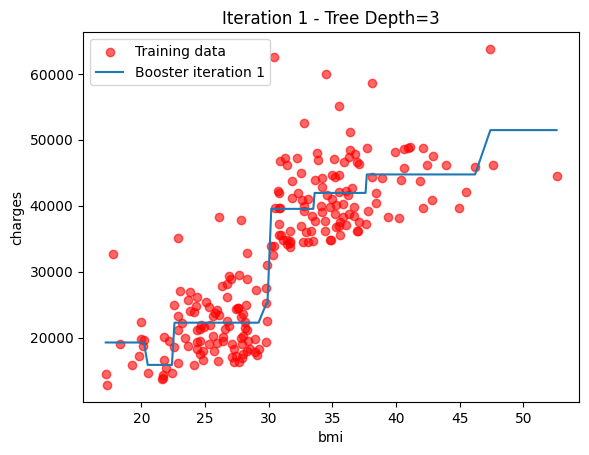

Iteration 2 | Train MSE: 24800602.27, Valid MSE: 21321894.71


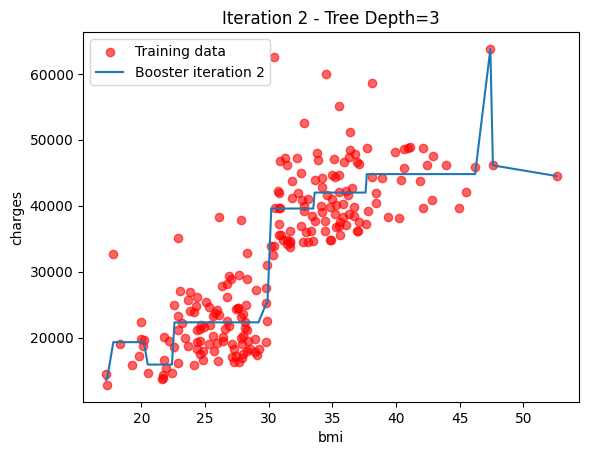

Iteration 3 | Train MSE: 22961903.73, Valid MSE: 26518659.18


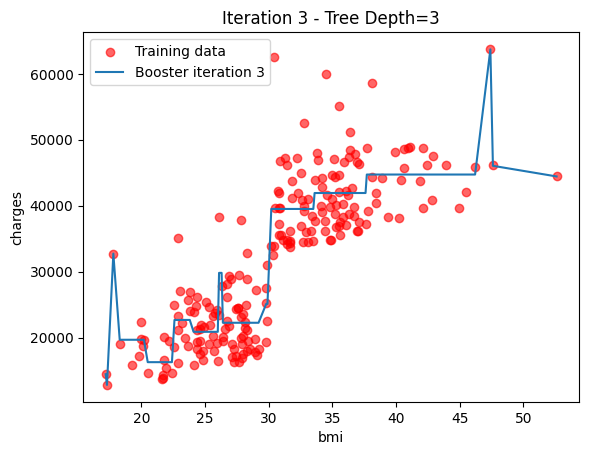

Iteration 4 | Train MSE: 22035708.95, Valid MSE: 27210137.28


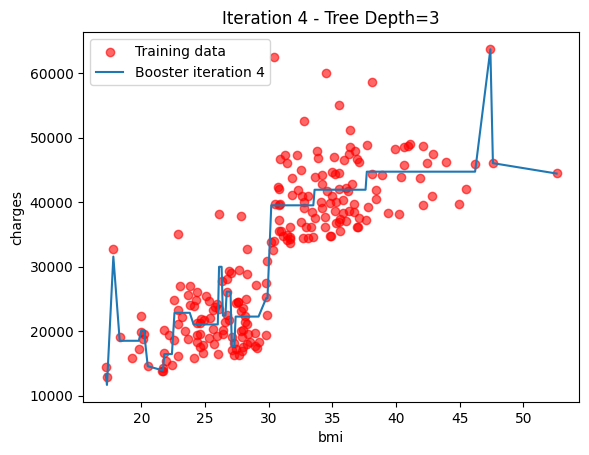

Iteration 5 | Train MSE: 21481915.27, Valid MSE: 27028034.04


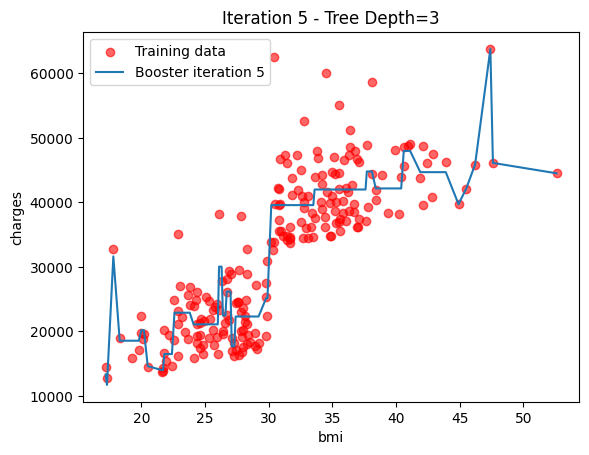

Iteration 6 | Train MSE: 20381627.02, Valid MSE: 27657685.68
Iteration 7 | Train MSE: 20036551.95, Valid MSE: 27684330.76
Iteration 8 | Train MSE: 18887750.37, Valid MSE: 29534276.50
Iteration 9 | Train MSE: 17560433.45, Valid MSE: 34694777.33
Iteration 10 | Train MSE: 15507780.39, Valid MSE: 33880440.88


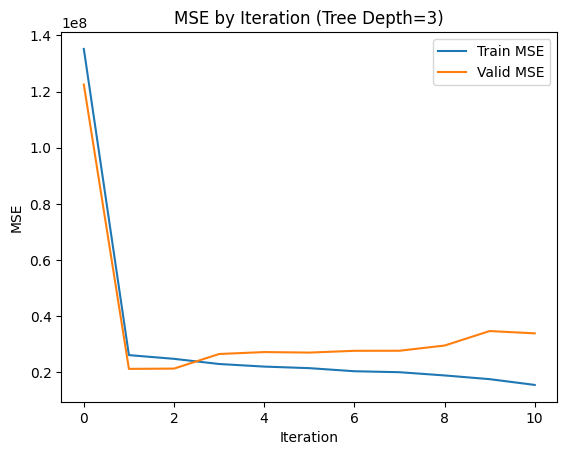

Optimal iteration (depth=3) = 1,  MSE=21228023.56


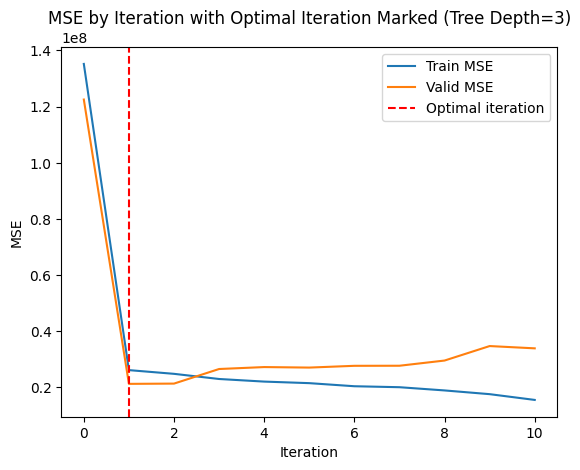

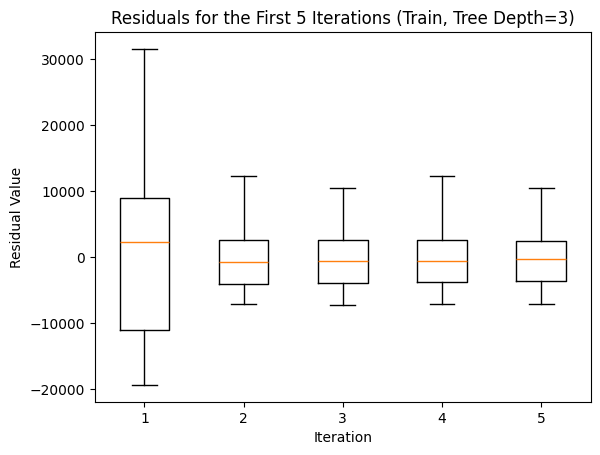

In [19]:
#######################
# Prepare fresh DataFrames
#######################
# It's usually clean to reset your DataFrames to their original state,
# especially if they've accumulated columns. We'll start from scratch
# but keep only the smokers with sorted BMI, as before.

dat2 = pd.concat([X_train[x], y_train], axis=1)
dat2 = dat2.loc[X_train['smoker_yes'] == 1, :]
dat2 = dat2.sort_values(x)

dat_valid2 = pd.concat([X_test[x], y_test], axis=1)
dat_valid2 = dat_valid2.loc[X_test['smoker_yes'] == 1, :]
dat_valid2 = dat_valid2.sort_values(x)

# Mean of charges for smokers (training)
mean_y2 = dat2[y].mean()

# Initialize predictions to the mean, iteration 0
dat2["pred0"] = mean_y2
dat_valid2["pred0"] = mean_y2

# We'll track MSE in new lists
mse_boosters_depth3 = [
    mean_squared_error(dat2[y], dat2["pred0"])
]
mse_boosters_valid_depth3 = [
    mean_squared_error(dat_valid2[y], dat_valid2["pred0"])
]

#######################
# Perform boosting iterations with max_depth=3
#######################
nBoost = 10
nPlotBoost = 5

for i_run in range(nBoost):
    # 1) Calculate residuals
    res_train = dat2[y] - dat2[f"pred{i_run}"]
    
    # 2) Fit a decision tree with max_depth=3
    tree_depth3 = DecisionTreeRegressor(max_depth=3, random_state=SEED)
    tree_depth3.fit(dat2[[x]], res_train)
    
    # 3) Predict residuals on train and validation
    rhat_train = tree_depth3.predict(dat2[[x]])
    rhat_valid = tree_depth3.predict(dat_valid2[[x]])
    
    # 4) Update current predictions
    dat2[f"pred{i_run + 1}"] = dat2[f"pred{i_run}"] + rhat_train
    dat_valid2[f"pred{i_run + 1}"] = dat_valid2[f"pred{i_run}"] + rhat_valid
    
    # 5) Compute MSE and store
    mse_boosters_depth3.append(
        mean_squared_error(dat2[y], dat2[f"pred{i_run + 1}"])
    )
    mse_boosters_valid_depth3.append(
        mean_squared_error(dat_valid2[y], dat_valid2[f"pred{i_run + 1}"])
    )
    
    print(f"Iteration {i_run+1} | "
          f"Train MSE: {mse_boosters_depth3[-1]:.2f}, "
          f"Valid MSE: {mse_boosters_valid_depth3[-1]:.2f}")
    
    # Optional quick plot for the first few iterations
    if i_run < nPlotBoost:
        plt.scatter(dat2[x], dat2[y], color='red', alpha=0.6, label='Training data')
        plt.plot(dat2[x], dat2[f"pred{i_run+1}"], label=f'Booster iteration {i_run+1}')
        plt.title(f'Iteration {i_run+1} - Tree Depth=3')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.show()

#######################
# Plot MSE curves for depth=3
#######################
plt.plot(range(len(mse_boosters_depth3)), mse_boosters_depth3, label='Train MSE')
plt.plot(range(len(mse_boosters_valid_depth3)), mse_boosters_valid_depth3, label='Valid MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE by Iteration (Tree Depth=3)')
plt.legend()
plt.show()

# Find the optimal iteration for depth=3
best_iter_depth3 = np.argmin(mse_boosters_valid_depth3)
print(f"Optimal iteration (depth=3) = {best_iter_depth3}, ",
      f"MSE={mse_boosters_valid_depth3[best_iter_depth3]:.2f}")

# Mark that on the plot
plt.plot(range(len(mse_boosters_depth3)), mse_boosters_depth3, label='Train MSE')
plt.plot(range(len(mse_boosters_valid_depth3)), mse_boosters_valid_depth3, label='Valid MSE')
plt.axvline(x=best_iter_depth3, color='r', linestyle='--', label='Optimal iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE by Iteration with Optimal Iteration Marked (Tree Depth=3)')
plt.legend()
plt.show()

#######################
# Boxplots of residuals for the first 5 iterations
#######################
# Compute residuals for the first 5 iterations
for i in range(6):  # up to iteration 5
    col_pred = f"pred{i}"
    col_res = f"res{i}"
    dat2[col_res] = dat2[y] - dat2[col_pred]

residual_data_depth3 = [dat2[f"res{i}"] for i in range(5)]
plt.boxplot(residual_data_depth3, showfliers=False)
plt.title('Residuals for the First 5 Iterations (Train, Tree Depth=3)')
plt.xlabel('Iteration')
plt.ylabel('Residual Value')
plt.show()



We used a <b>more complex booster</b> as we set max_depth = 3 instead of the original max_depth = 1 ("stump"). Therefore the <b>number of iterations</b> to achieve a minimum is much <b>lower</b> than before. The MSE is almost the same.<br>

<font color='DodgerBlue'>
<b>Quastion 1</b>: The number of iterations in the second model is much lower. Does this automatically mean that fitting will take lower time? <br>
<b>Answer 1</b>: Automatically no, as fitting more complex trees in each iteration will take more time than in the case of stumps. <br>
</font>

The tree complexity (given e.g. by the max_depth) and the number of iterations are <b>hyper-parameters</b> of the model and should be optimized for example using a grid.